In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface


In [8]:
file_list = os.listdir(f"/media/ubuntu/sda/mouse_test/raw_data/20251120_xiaoqiang_EEG_251120_225259")
file_list.remove("settings.xml")
file_list = sorted(file_list)
file_list.remove("20251120_xiaoqiang_EEG_251121_015559.rhs")
recording_raw_list = []
trigger_list = []
for file in file_list:
    #recording_raw_list.append(se.read_intan(f"/media/ubuntu/sda/mouse_test/raw_data/20251120_xiaoqiang_EEG_251120_225259/{file}", stream_id= '0'))
    trigger_list.append(se.read_intan(f"/media/ubuntu/sda/mouse_test/raw_data/20251120_xiaoqiang_EEG_251120_225259/{file}", stream_id= '3'))
#recording_raw = concatenate_recordings(recording_list=recording_raw_list)
trigger = concatenate_recordings(recording_list=trigger_list)
trigger = spre.unsigned_to_signed(trigger)
#trigger = spre.bandpass_filter(trigger, freq_min=300, freq_max=3000)
# recording_recorded = spre.notch_filter(recording_recorded, freq=50)
# recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

<Axes: >

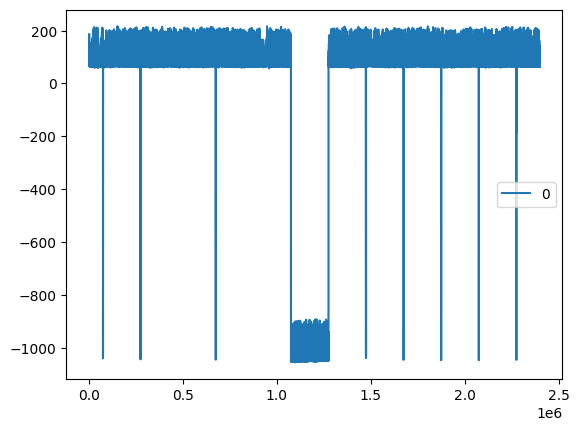

In [9]:
sns.lineplot(trigger.get_traces()[4 * 60 * 20000:6 * 60 * 20000])

In [23]:
recording_raw_list[0]

IntanRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 1,200,000 samples 
                         60.00s (1.00 minutes) - uint16 dtype - 73.24 MiB
  file_path: /media/ubuntu/sda/mouse_test/raw_data/20251120_xiaoqiang_EEG_251120_225259/20251120_xiaoqiang_EEG_251120_225259.rhs

In [45]:
probe_30channel = read_probeinterface('/media/ubuntu/sda/mouse_test/probe/brainstem_32ch.json')
recording_f = recording_f.set_probegroup(probe_30channel)

In [ ]:
output_folder = '/media/ubuntu/sda/mouse_test/sorted/20251120_xiaoqiang_EEG_251120_225259'
recording_preprocessed = recording_f.save(format="binary")
print(recording_preprocessed)

sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "noise_levels",
    "templates",
    "spike_amplitudes",
    "unit_locations",
    "spike_locations",
    "correlograms",
    "template_similarity"
]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

Use cache_folder=/tmp/spikeinterface_cache/tmpl5r7vkoc/EMNBUH5D
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=20,000 - chunk_memory=1.22 MiB - total_memory=1.22 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/10980 [00:00<?, ?it/s]

BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 219,600,000 samples 
                       10,980.00s (3.05 hours) - int16 dtype - 13.09 GiB


  0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
def load_cluster_info(phy_dir: str) -> pd.DataFrame:
    """读取 phy_folder_for_kilosort/cluster_info.tsv 为 DataFrame。
    该表包含所有需要的 cluster 级指标。
    如果cluster_info.tsv不存在，则尝试从其他文件构建基本信息。
    同时计算并添加mean_waveform信息。
    """
    path = os.path.join(phy_dir, CLUSTER_INFO_FILENAME)
    
    if os.path.exists(path):
        df = pd.read_csv(path, sep='\t')
        # 标准化主键列名
        if 'cluster_id' not in df.columns:
            raise ValueError(f"{path} 中缺少 cluster_id 列")
    else:
        print(f"警告: {path} 不存在，尝试从其他文件构建cluster信息")
        
        # 尝试从cluster_group.tsv构建基本信息
        cluster_group_path = os.path.join(phy_dir, "cluster_group.tsv")
        if os.path.exists(cluster_group_path):
            df = pd.read_csv(cluster_group_path, sep='\t')
            if 'cluster_id' not in df.columns:
                raise ValueError(f"{cluster_group_path} 中缺少 cluster_id 列")
        else:
            # 如果都没有，从spike_clusters.npy中提取唯一的cluster_id
            spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
            if os.path.exists(spike_clusters_path):
                spike_clusters = np.load(spike_clusters_path)
                unique_clusters = np.unique(spike_clusters)
                df = pd.DataFrame({
                    'cluster_id': unique_clusters,
                    'group': 'unsorted'  # 默认分组
                })
            else:
                raise ValueError(f"无法找到任何cluster信息文件: {phy_dir}")
    
    # 计算mean_waveform并展开为多列添加到DataFrame
    mean_waveforms = compute_mean_waveform(phy_dir)
    if mean_waveforms:
        # 确定waveform的长度（通常是90个时间点）
        waveform_length = None
        for waveform in mean_waveforms.values():
            if waveform is not None:
                waveform_length = len(waveform)
                break
        
        if waveform_length is not None:
            # 创建waveform列名
            waveform_columns = [f'mean_waveform_{i}' for i in range(waveform_length)]
            
            # 为每个cluster创建waveform数据
            waveform_data = {}
            for cluster_id in df['cluster_id']:
                if cluster_id in mean_waveforms and mean_waveforms[cluster_id] is not None:
                    waveform = mean_waveforms[cluster_id]
                    # 确保waveform长度一致
                    if len(waveform) == waveform_length:
                        waveform_data[cluster_id] = waveform
                    else:
                        # 如果长度不匹配，用NaN填充或截断
                        padded_waveform = np.full(waveform_length, np.nan)
                        padded_waveform[:min(len(waveform), waveform_length)] = waveform[:min(len(waveform), waveform_length)]
                        waveform_data[cluster_id] = padded_waveform
                else:
                    # 没有waveform数据的cluster用NaN填充
                    waveform_data[cluster_id] = np.full(waveform_length, np.nan)
            
            # 将waveform数据转换为DataFrame并合并
            waveform_df = pd.DataFrame.from_dict(waveform_data, orient='index', columns=waveform_columns)
            waveform_df.index.name = 'cluster_id'
            waveform_df = waveform_df.reset_index()
            
            # 合并到主DataFrame
            df = df.merge(waveform_df, on='cluster_id', how='left')
            print(f"成功添加mean_waveform信息到 {len(mean_waveforms)} 个clusters，展开为 {waveform_length} 列")
        else:
            print("警告: 无法确定waveform长度")
    else:
        print("警告: 无法计算mean_waveform信息")
    
    return df


def load_spike_level(phy_dir: str) -> pd.DataFrame:
    """读取 spike 层面的 numpy 文件并返回 DataFrame: [cluster, time]
    time 使用原始采样点，不做单位转换。
    """
    spike_clusters = np.load(os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME))
    spike_times = np.load(os.path.join(phy_dir, SPIKE_TIMES_FILENAME))
    # 展平为一维
    spike_clusters = np.asarray(spike_clusters).reshape(-1)
    spike_times = np.asarray(spike_times).reshape(-1)
    if spike_clusters.shape[0] != spike_times.shape[0]:
        raise ValueError(f"spike_clusters 与 spike_times 行数不一致: {phy_dir}")
    df = pd.DataFrame({
        'cluster_id': spike_clusters.astype(int),
        'time': spike_times.astype(int),
    })
    return df


def compute_mean_waveform(phy_dir: str) -> dict:
    """计算每个cluster的平均波形
    
    Returns:
        dict: {cluster_id: mean_waveform_array}
    """
    templates_path = os.path.join(phy_dir, "templates.npy")
    spike_templates_path = os.path.join(phy_dir, "spike_templates.npy")
    spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
    
    if not all(os.path.exists(p) for p in [templates_path, spike_templates_path, spike_clusters_path]):
        print("警告: 缺少计算waveform所需的文件，跳过mean_waveform计算")
        return {}
    
    # 加载数据
    templates = np.load(templates_path)  # shape: (n_templates, n_timepoints, n_channels)
    spike_templates = np.load(spike_templates_path).flatten()  # shape: (n_spikes,)
    spike_clusters = np.load(spike_clusters_path).flatten()  # shape: (n_spikes,)
    
    # 创建cluster到template的映射
    cluster_template_map = {}
    for spike_idx, (cluster_id, template_id) in enumerate(zip(spike_clusters, spike_templates)):
        if cluster_id not in cluster_template_map:
            cluster_template_map[cluster_id] = template_id
    
    # 计算每个cluster的mean_waveform
    mean_waveforms = {}
    for cluster_id, template_id in cluster_template_map.items():
        if template_id < templates.shape[0]:
            # 获取该cluster对应的template
            template = templates[template_id]  # shape: (n_timepoints, n_channels)
            # 如果模板是2D的，取第一个通道或平均所有通道
            if template.ndim == 2:
                if template.shape[1] == 1:
                    # 只有一个通道
                    mean_waveform = template[:, 0]
                else:
                    # 多个通道，取平均
                    mean_waveform = np.mean(template, axis=1)
            else:
                # 1D情况
                mean_waveform = template
            mean_waveforms[cluster_id] = mean_waveform
    
    return mean_waveforms

In [9]:
CLUSTER_INFO_FILENAME = "cluster_info.tsv"

SPIKE_CLUSTERS_FILENAME = "spike_clusters.npy"
SPIKE_TIMES_FILENAME = "spike_times.npy"

In [10]:
ROOT_SORT_DIR = "/media/ubuntu/sda/mouse_test/sorted/20251109_RBDPD_1_251109_204016/phy_folder_for_kilosort"
cluster_inf = load_cluster_info(phy_dir=ROOT_SORT_DIR)
spike_inf = load_spike_level(phy_dir=ROOT_SORT_DIR)
cluster_inf = cluster_inf[(cluster_inf['group'] == 'good')]
spike_inf = spike_inf[spike_inf['cluster_id'].isin(cluster_inf['cluster_id'].values)]

成功添加mean_waveform信息到 47 个clusters，展开为 60 列


已保存: waveform_grid.pdf


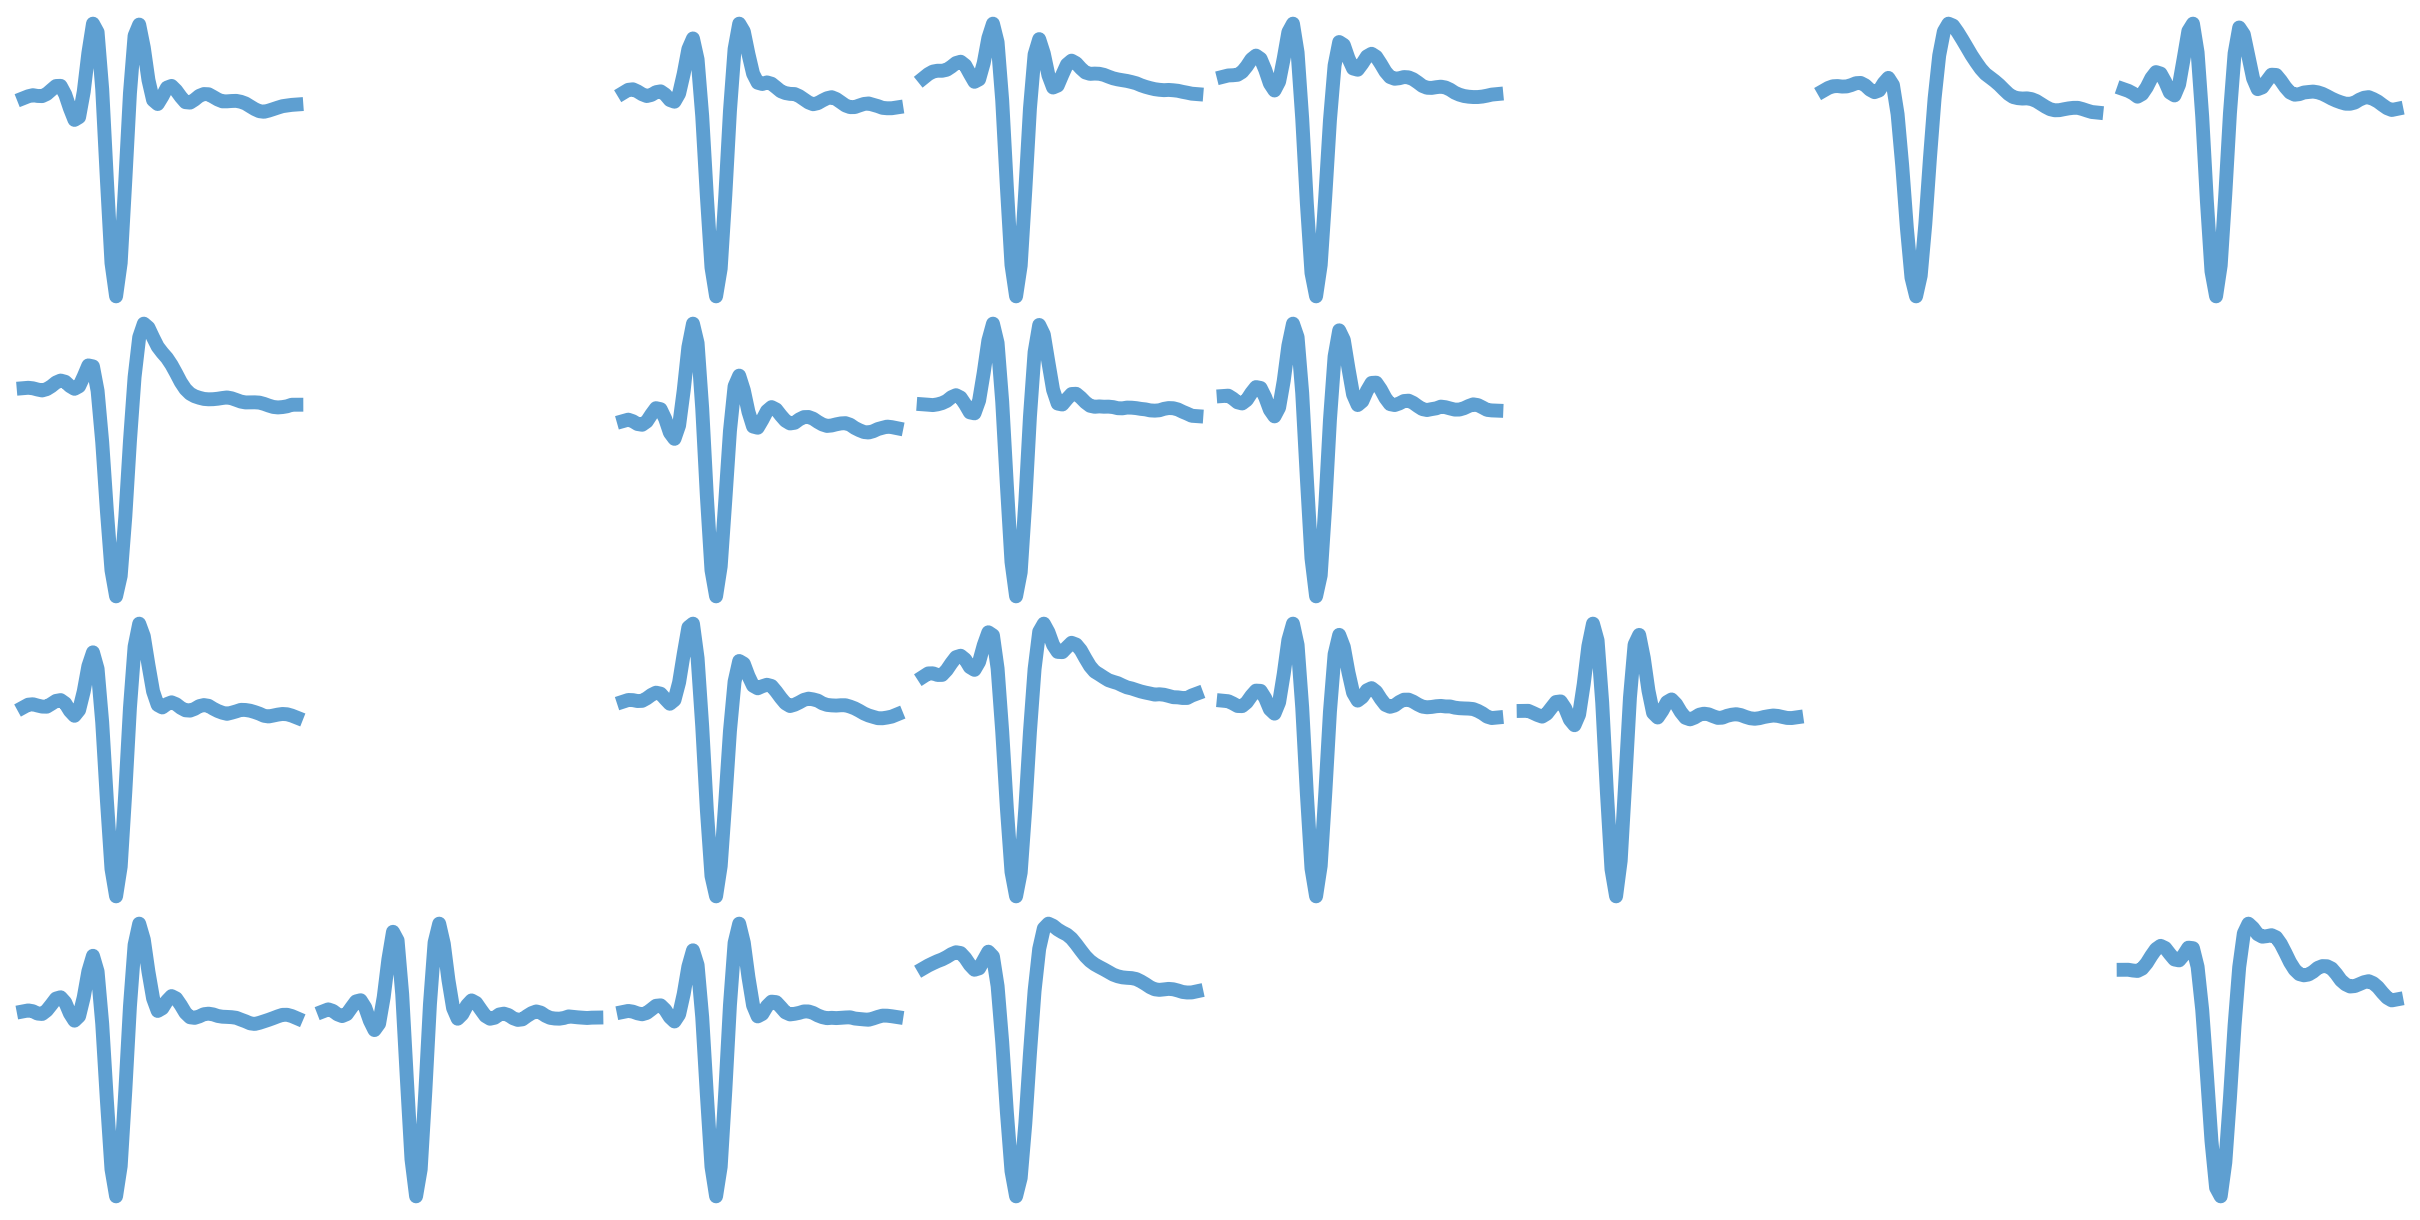

In [16]:
def plot_waveform_grid(cluster_inf_all, date, n_rows=4, n_cols=8, figsize=(24, 12), output_name=None):
    """
    绘制单个日期的waveform网格图，16×16布局，每个子图代表一个channel
    两天都能追踪到的cluster: #ED7B85（红色）
    只在当前这一天出现的cluster: #5E9FD1（蓝色）
    
    Parameters:
    -----------
    cluster_inf_all : DataFrame
        包含cluster信息和waveform数据，必须包含neuron列
    date : int
        要绘制的日期（1或2）
    n_rows : int
        行数，默认16
    n_cols : int
        列数，默认16
    figsize : tuple
        图形大小
    output_name : str
        输出PDF文件名，如果为None则不保存
    """
    
    # 筛选指定日期的数据
    
    waveform_cols = [col for col in cluster_inf_all.columns if col.startswith('mean_waveform_')]
    

    fig = plt.figure(figsize=figsize)
    
    # 对每个channel绘制
    for ch in range(n_rows * n_cols):
        ax = plt.subplot(n_rows, n_cols, ch + 1)
        
        # 获取该channel的所有clusters
        ch_clusters = cluster_inf_all[cluster_inf_all['ch'] == ch]
        
        if len(ch_clusters) > 0:
            # 绘制该channel的所有clusters的waveform
            for idx, row in ch_clusters.iterrows():
                waveform = row[waveform_cols].values.astype(float)
                
                color = '#5E9FD1'  # 蓝色：只在当前这一天
                    
                ax.plot(waveform, color=color, linewidth=10, alpha=1)
        
        ax.axis('off')
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    
    if output_name:
        plt.savefig(output_name, dpi=150, bbox_inches='tight')
        print(f"已保存: {output_name}")
    
    plt.show()
    

plot_waveform_grid(cluster_inf, date=1, output_name='waveform_grid.pdf')